# Diabetes Prediction Analysis 

This notebook addresses data quality issues including age outliers and improves model performance for better recall.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import joblib

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Load and Examine the Dataset for Outliers

Let's identify and address data quality issues including the age outlier.

In [2]:
# Load the diabetes dataset
df = pd.read_csv('diabetes_dataset.csv')

# Remove duplicates
df_cleaned = df.drop_duplicates()

print('Dataset shape after removing duplicates:', df_cleaned.shape)
print('\nInitial data inspection:')
print(df_cleaned.describe())

# Check for outliers in age
print('\nAge distribution analysis:')
print(f'Min age: {df_cleaned["age"].min()}')
print(f'Max age: {df_cleaned["age"].max()}')
print(f'Age < 1: {(df_cleaned["age"] < 1).sum()} records')
print(f'Age > 100: {(df_cleaned["age"] > 100).sum()} records')
print(f'Age < 18: {(df_cleaned["age"] < 18).sum()} records')

# Check for outliers in other numerical features
print('\nBMI distribution analysis:')
print(f'Min BMI: {df_cleaned["bmi"].min()}')
print(f'Max BMI: {df_cleaned["bmi"].max()}')
print(f'BMI < 10: {(df_cleaned["bmi"] < 10).sum()} records')
print(f'BMI > 100: {(df_cleaned["bmi"] > 100).sum()} records')

print('\nHbA1c distribution analysis:')
print(f'Min HbA1c: {df_cleaned["hbA1c_level"].min()}')
print(f'Max HbA1c: {df_cleaned["hbA1c_level"].max()}')
print(f'HbA1c < 2: {(df_cleaned["hbA1c_level"] < 2).sum()} records')
print(f'HbA1c > 20: {(df_cleaned["hbA1c_level"] > 20).sum()} records')

print('\nBlood glucose distribution analysis:')
print(f'Min glucose: {df_cleaned["blood_glucose_level"].min()}')
print(f'Max glucose: {df_cleaned["blood_glucose_level"].max()}')
print(f'Glucose < 50: {(df_cleaned["blood_glucose_level"] < 50).sum()} records')
print(f'Glucose > 500: {(df_cleaned["blood_glucose_level"] > 500).sum()} records')

Dataset shape after removing duplicates: (99986, 16)

Initial data inspection:
               year           age  race:AfricanAmerican    race:Asian  \
count  99986.000000  99986.000000          99986.000000  99986.000000   
mean    2018.360731     41.885930              0.202238      0.200098   
std        1.345312     22.516409              0.401671      0.400075   
min     2015.000000      0.080000              0.000000      0.000000   
25%     2019.000000     24.000000              0.000000      0.000000   
50%     2019.000000     43.000000              0.000000      0.000000   
75%     2019.000000     60.000000              0.000000      0.000000   
max     2022.000000     80.000000              1.000000      1.000000   

       race:Caucasian  race:Hispanic    race:Other  hypertension  \
count    99986.000000   99986.000000  99986.000000  99986.000000   
mean         0.198758       0.198898      0.200008      0.074860   
std          0.399067       0.399173      0.400008      0.2

## 2. Comprehensive Data Cleaning and Outlier Treatment

Address outliers and invalid values in the dataset.

Before cleaning:
Dataset shape: (99986, 16)
Diabetes distribution: {0: 91486, 1: 8500}

After removing age outliers (<1 or >120): (99075, 16)
After removing BMI outliers (<10 or >100): (99075, 16)
After removing HbA1c outliers (<2 or >20): (99075, 16)
After removing glucose outliers (<50 or >500): (99075, 16)

Final dataset shape: (99075, 16)
Diabetes distribution after cleaning: {0: 90575, 1: 8500}
Class distribution: {0: 0.9142064092858945, 1: 0.08579359071410547}


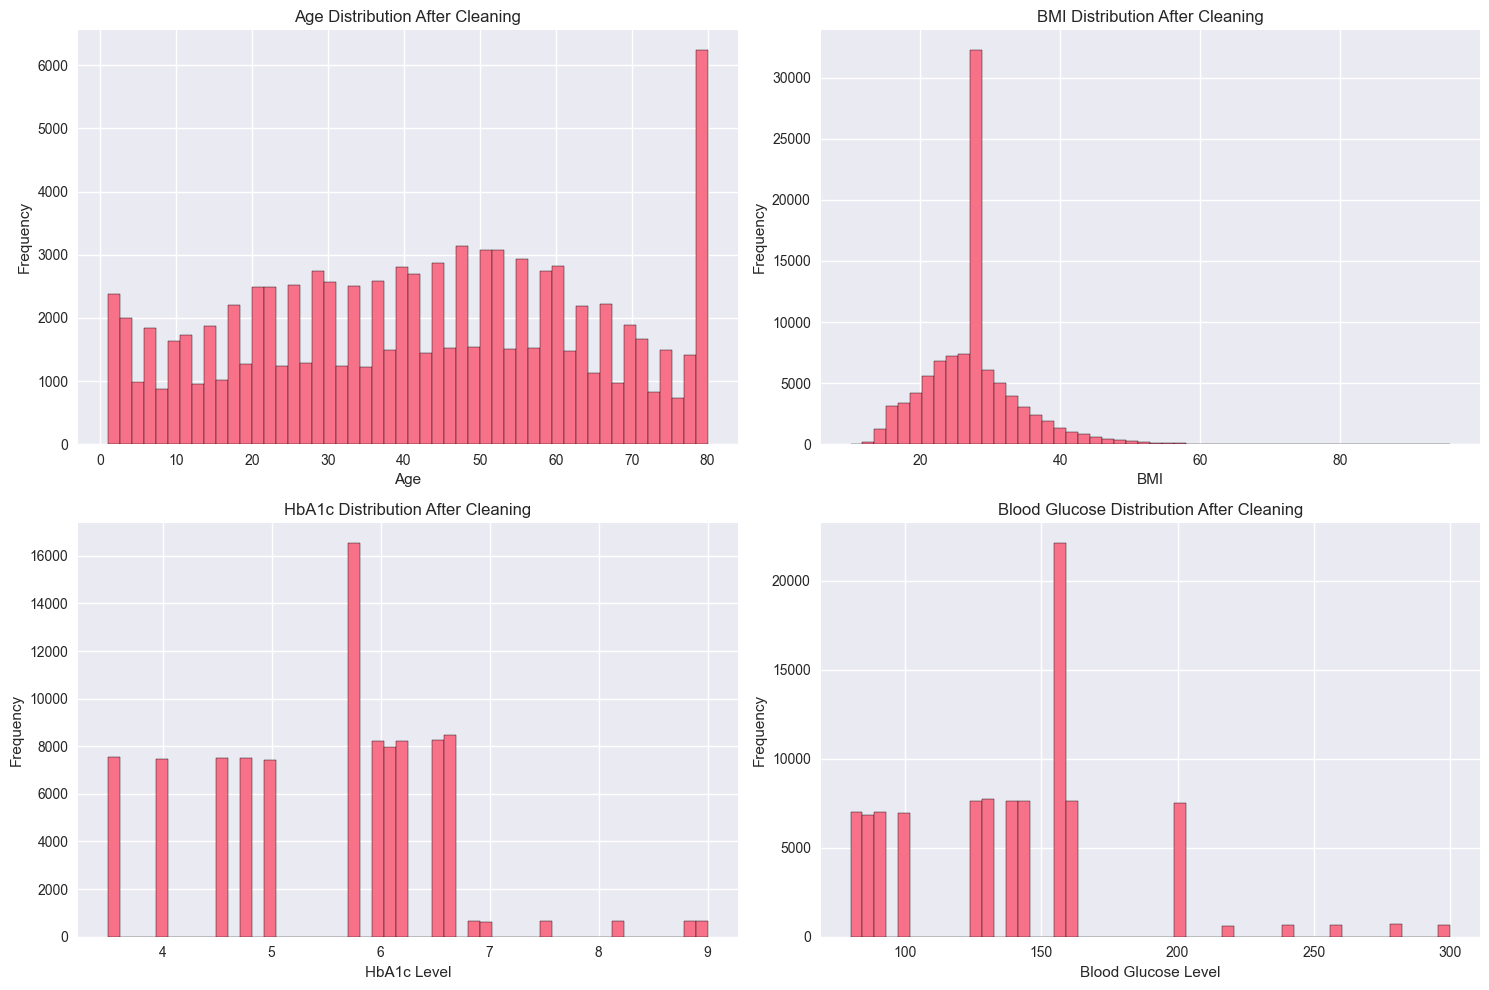

In [3]:
# Create a copy for cleaning
df_processed = df_cleaned.copy()

print('Before cleaning:')
print(f'Dataset shape: {df_processed.shape}')
print(f'Diabetes distribution: {df_processed["diabetes"].value_counts().to_dict()}')

# Remove records with impossible ages (< 1 year or > 120 years)
df_processed = df_processed[(df_processed['age'] >= 1) & (df_processed['age'] <= 120)]
print(f'\nAfter removing age outliers (<1 or >120): {df_processed.shape}')

# Remove records with impossible BMI values (< 10 or > 100)
df_processed = df_processed[(df_processed['bmi'] >= 10) & (df_processed['bmi'] <= 100)]
print(f'After removing BMI outliers (<10 or >100): {df_processed.shape}')

# Remove records with impossible HbA1c values (< 2 or > 20)
df_processed = df_processed[(df_processed['hbA1c_level'] >= 2) & (df_processed['hbA1c_level'] <= 20)]
print(f'After removing HbA1c outliers (<2 or >20): {df_processed.shape}')

# Remove records with impossible blood glucose values (< 50 or > 500)
df_processed = df_processed[(df_processed['blood_glucose_level'] >= 50) & (df_processed['blood_glucose_level'] <= 500)]
print(f'After removing glucose outliers (<50 or >500): {df_processed.shape}')

# Check remaining data
print(f'\nFinal dataset shape: {df_processed.shape}')
print(f'Diabetes distribution after cleaning: {df_processed["diabetes"].value_counts().to_dict()}')
print(f'Class distribution: {df_processed["diabetes"].value_counts(normalize=True).to_dict()}')

# Visualize the cleaned data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(df_processed['age'], bins=50, edgecolor='black')
axes[0,0].set_title('Age Distribution After Cleaning')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')

axes[0,1].hist(df_processed['bmi'], bins=50, edgecolor='black')
axes[0,1].set_title('BMI Distribution After Cleaning')
axes[0,1].set_xlabel('BMI')
axes[0,1].set_ylabel('Frequency')

axes[1,0].hist(df_processed['hbA1c_level'], bins=50, edgecolor='black')
axes[1,0].set_title('HbA1c Distribution After Cleaning')
axes[1,0].set_xlabel('HbA1c Level')
axes[1,0].set_ylabel('Frequency')

axes[1,1].hist(df_processed['blood_glucose_level'], bins=50, edgecolor='black')
axes[1,1].set_title('Blood Glucose Distribution After Cleaning')
axes[1,1].set_xlabel('Blood Glucose Level')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Advanced Feature Engineering

Create new features that might improve model performance.

In [4]:
# Create new features
df_features = df_processed.copy()

# Age groups
df_features['age_group'] = pd.cut(df_features['age'], 
                                 bins=[0, 18, 35, 50, 65, 100], 
                                 labels=['Under 18', '18-35', '36-50', '51-65', 'Over 65'])

# BMI categories
df_features['bmi_category'] = pd.cut(df_features['bmi'], 
                                    bins=[0, 18.5, 25, 30, 100], 
                                    labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Risk scores
df_features['risk_score'] = (
    (df_features['age'] > 40).astype(int) +
    (df_features['bmi'] > 30).astype(int) +
    (df_features['hbA1c_level'] > 6.5).astype(int) +
    (df_features['blood_glucose_level'] > 140).astype(int) +
    df_features['hypertension'] +
    df_features['heart_disease']
)

# Interaction features
df_features['age_bmi_interaction'] = df_features['age'] * df_features['bmi']
df_features['glucose_hba1c_interaction'] = df_features['blood_glucose_level'] * df_features['hbA1c_level']

# Encode categorical variables ( this will help models can eaiser to understand instead of text become an integer )
le_gender = LabelEncoder()
df_features['gender_encoded'] = le_gender.fit_transform(df_features['gender'])

le_smoking = LabelEncoder()
df_features['smoking_history_encoded'] = le_smoking.fit_transform(df_features['smoking_history'])

le_age_group = LabelEncoder()
df_features['age_group_encoded'] = le_age_group.fit_transform(df_features['age_group'])

le_bmi_category = LabelEncoder()
df_features['bmi_category_encoded'] = le_bmi_category.fit_transform(df_features['bmi_category'])

print('New features created:')
print(f'Total features: {len([col for col in df_features.columns if not col.startswith("race:")])}')
print(f'Risk score distribution: {df_features["risk_score"].value_counts().sort_index().to_dict()}')

New features created:
Total features: 20
Risk score distribution: {0: 18682, 1: 35671, 2: 27319, 3: 12381, 4: 4050, 5: 891, 6: 81}


## 4. Prepare Features and Target with Advanced Scaling

Use RobustScaler to handle remaining outliers and prepare data for modeling.

In [5]:
# Select features for modeling
feature_columns = [
    'year', 'gender_encoded', 'age', 'age_group_encoded', 'bmi', 'bmi_category_encoded',
    'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other',
    'hypertension', 'heart_disease', 'smoking_history_encoded', 'hbA1c_level',
    'blood_glucose_level', 'risk_score', 'age_bmi_interaction', 'glucose_hba1c_interaction'
]

X = df_features[feature_columns]
y = df_features['diabetes']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Use RobustScaler to handle outliers
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')
print(f'Training set diabetes rate: {y_train.mean():.3f}')
print(f'Test set diabetes rate: {y_test.mean():.3f}')

Training set size: 79260
Test set size: 19815
Training set diabetes rate: 0.086
Test set diabetes rate: 0.086


## 5. Handle Class Imbalance with Advanced Techniques

Use SMOTETomek to both oversample minority class and clean noisy samples.

In [6]:
# Apply SMOTETomek to handle class imbalance
print('Before SMOTETomek:')
print(f'Training set shape: {X_train_scaled.shape}')
print(f'Class distribution in training set: {np.bincount(y_train)}')

smote_tomek = SMOTETomek(random_state=42)
X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_scaled, y_train)

print('\nAfter SMOTETomek:')
print(f'Training set shape: {X_train_balanced.shape}')
print(f'Class distribution in balanced training set: {np.bincount(y_train_balanced)}')

# Calculate class weights for models
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print(f'\nClass weights: {class_weight_dict}')

Before SMOTETomek:
Training set shape: (79260, 19)
Class distribution in training set: [72460  6800]

After SMOTETomek:
Training set shape: (144608, 19)
Class distribution in balanced training set: [72304 72304]

Class weights: {0: 0.5469224399668783, 1: 5.827941176470588}


## 6. Train Models with Class Weight Adjustment

Use class weights to penalize misclassification of the minority class.

In [7]:
# Initialize models with class weight adjustment
models = {
    'Logistic Regression (Weighted)': LogisticRegression(random_state=42, class_weight='balanced'),
    'Random Forest (Weighted)': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'SVM (Weighted)': SVC(kernel='rbf', random_state=42, class_weight='balanced')
}

# Train and store results
results_weighted = {}

print("Training and evaluating models with class weights...\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train_balanced, y_train_balanced)
    
    # Make predictions on the original (imbalanced) test set
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # Calculate AUC
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test_scaled)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results_weighted[name] = {
        'model': model,
        'accuracy': accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'auc': auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"{name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, AUC: {auc:.4f}")
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)
    
    # Save the trained model
    joblib.dump(model, f'{name.lower().replace(" ", "_").replace("(weighted)", "weighted")}_model.pkl')

print("\nTrained models with class weights saved as pickle files.")

Training and evaluating models with class weights...

Training Logistic Regression (Weighted)...
Logistic Regression (Weighted) - Accuracy: 0.8869, F1-Score: 0.5715, Precision: 0.4233, Recall: 0.8794, AUC: 0.9602
Classification Report for Logistic Regression (Weighted):
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     18115
           1       0.42      0.88      0.57      1700

    accuracy                           0.89     19815
   macro avg       0.71      0.88      0.75     19815
weighted avg       0.94      0.89      0.90     19815

--------------------------------------------------
Training Random Forest (Weighted)...
Random Forest (Weighted) - Accuracy: 0.9653, F1-Score: 0.7817, Precision: 0.8500, Recall: 0.7235, AUC: 0.9672
Classification Report for Random Forest (Weighted):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18115
           1       0.85      0.72      0.78

## 7. Fine-tune Threshold for Better Recall

Adjust classification threshold to optimize for recall in medical diagnosis.

In [8]:
from sklearn.metrics import precision_recall_curve

# Find optimal threshold for Random Forest model
rf_model = models['Random Forest (Weighted)']
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

# Calculate F1-scores for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores)  # Replace NaN with 0

# Find optimal threshold based on F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f'Random Forest - Optimal threshold: {optimal_threshold:.4f}')
print(f'Max F1-Score at optimal threshold: {f1_scores[optimal_idx]:.4f}')
print(f'At optimal threshold - Precision: {precisions[optimal_idx]:.4f}, Recall: {recalls[optimal_idx]:.4f}')

# Also try a threshold that prioritizes recall (sensitivity) for medical diagnosis
recall_focused_threshold = 0.3  # Lower threshold to increase recall
y_pred_recall_focused = (y_proba_rf >= recall_focused_threshold).astype(int)

print(f'\nWith recall-focused threshold ({recall_focused_threshold}):')
print(f'Accuracy: {accuracy_score(y_test, y_pred_recall_focused):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_recall_focused):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_recall_focused):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_recall_focused):.4f}')
print(f'AUC: {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'\nClassification Report (Recall-focused):')
print(classification_report(y_test, y_pred_recall_focused))

Random Forest - Optimal threshold: 0.7900
Max F1-Score at optimal threshold: 0.7973
At optimal threshold - Precision: 0.9895, Recall: 0.6676

With recall-focused threshold (0.3):
Accuracy: 0.9399
F1-Score: 0.7013
Precision: 0.6116
Recall: 0.8218
AUC: 0.9672

Classification Report (Recall-focused):
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     18115
           1       0.61      0.82      0.70      1700

    accuracy                           0.94     19815
   macro avg       0.80      0.89      0.83     19815
weighted avg       0.95      0.94      0.94     19815



## 8. Feature Importance Analysis

Identify the most important features for diabetes prediction.


Top 10 Most Important Features (Random Forest):
1. glucose_hba1c_interaction: 0.2304
2. hbA1c_level: 0.1844
3. blood_glucose_level: 0.1384
4. risk_score: 0.1228
5. age_bmi_interaction: 0.0952
6. age: 0.0716
7. smoking_history_encoded: 0.0424
8. bmi: 0.0365
9. age_group_encoded: 0.0322
10. gender_encoded: 0.0085


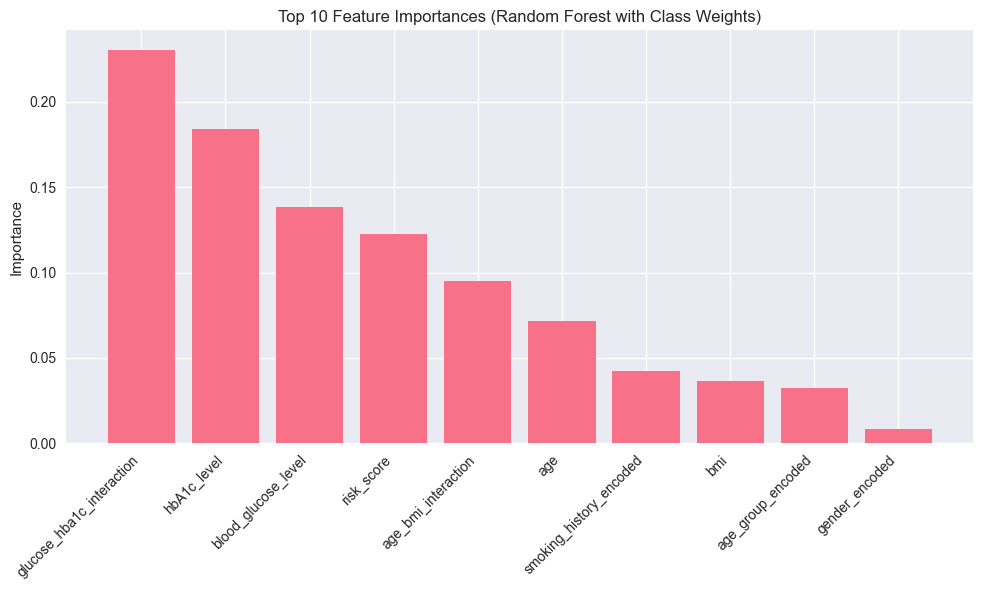

In [9]:
# Feature importance for Random Forest
rf_model = models['Random Forest (Weighted)']
feature_importance = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(feature_importance)[::-1]

print(f"\nTop 10 Most Important Features (Random Forest):")
for i in range(min(10, len(feature_columns))):
    idx = indices[i]
    print(f"{i+1}. {feature_columns[idx]}: {feature_importance[idx]:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
top_indices = indices[:10]
plt.bar(range(len(top_indices)), feature_importance[top_indices])
plt.xticks(range(len(top_indices)), [feature_columns[i] for i in top_indices], rotation=45, ha='right')
plt.title('Top 10 Feature Importances (Random Forest with Class Weights)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## 9. Model Comparison and Summary

Compare all models and summarize findings.

Performance Comparison of Models with Enhanced Preprocessing
                            Model  Accuracy  F1-Score  Precision    Recall  \
0  Logistic Regression (Weighted)  0.886853  0.571483   0.423273  0.879412   
1        Random Forest (Weighted)  0.965329  0.781697   0.850035  0.723529   
2                  SVM (Weighted)  0.888266  0.578607   0.427687  0.894118   

        AUC  
0  0.960167  
1  0.967174  
2  0.962569  


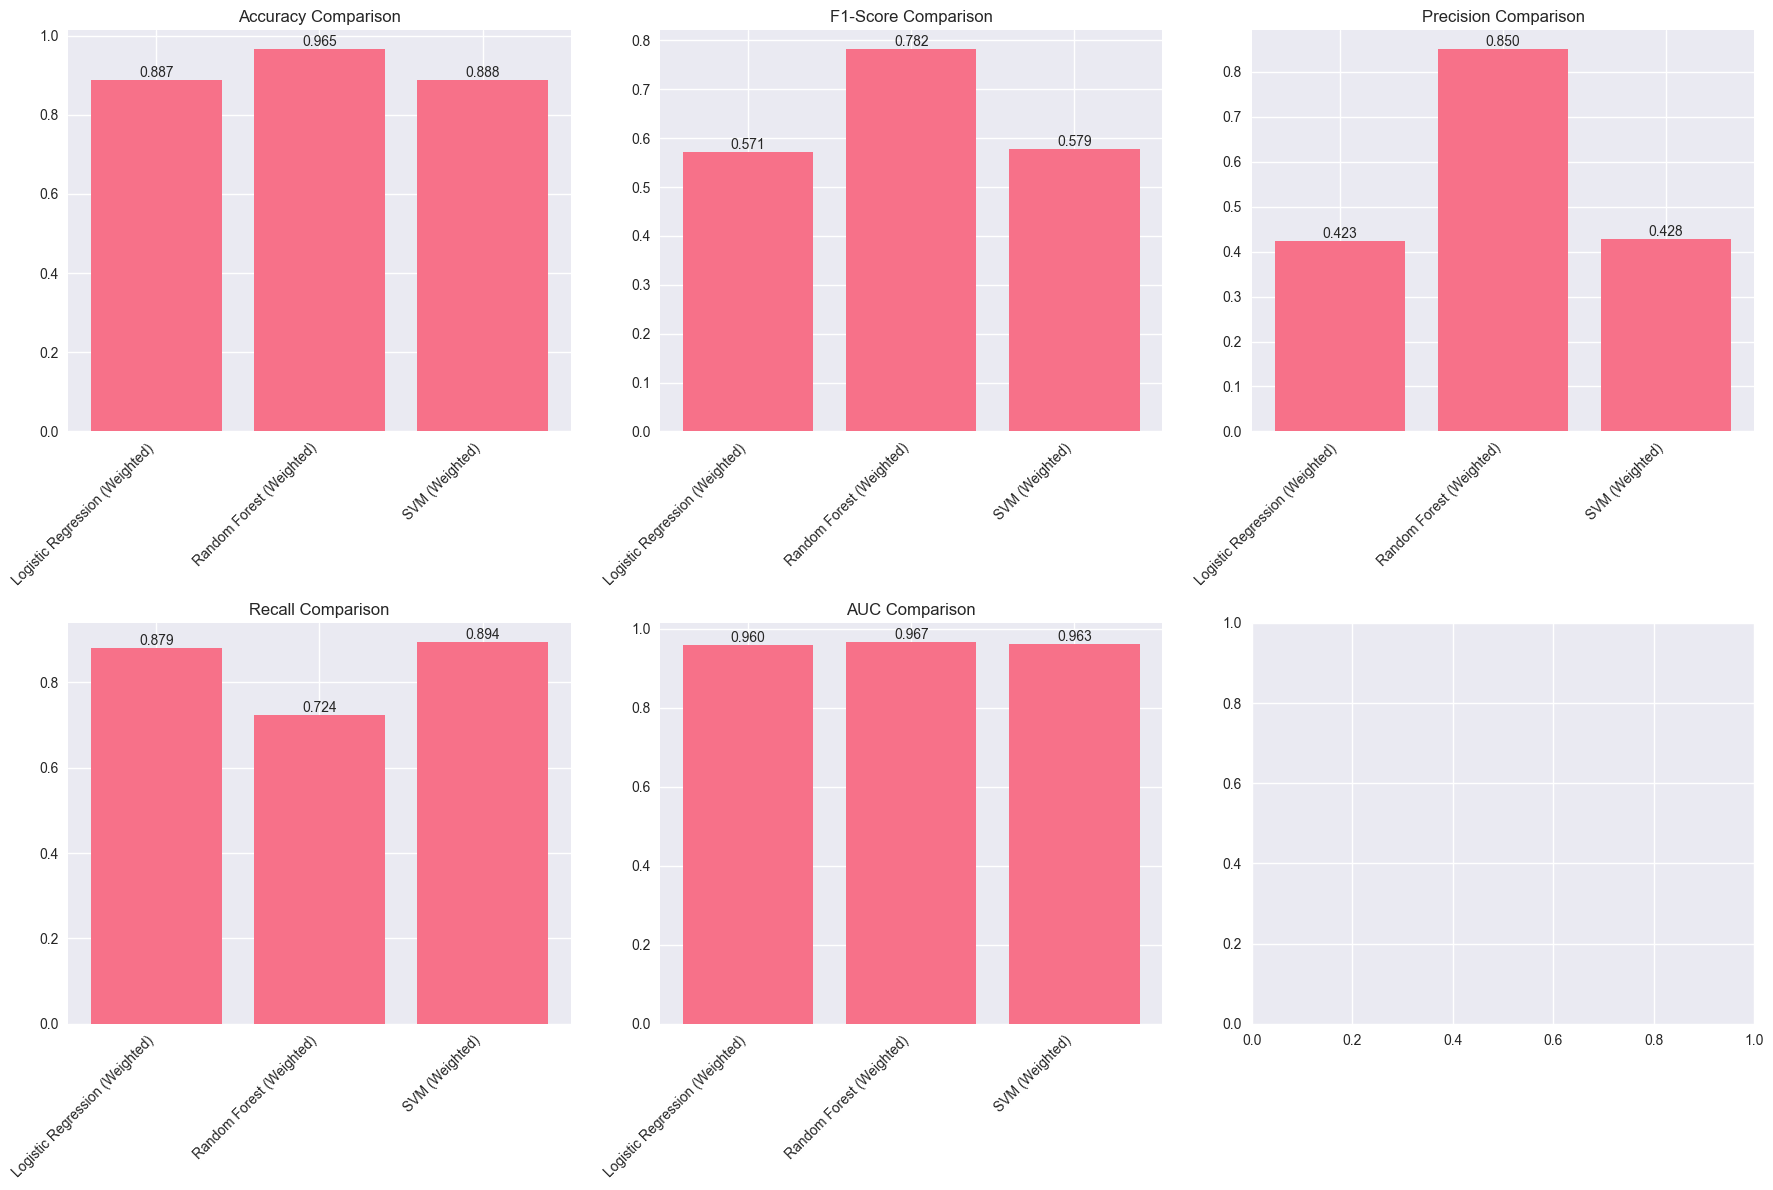

In [10]:
# Create comparison dataframe
comparison_data = []

for name, result in results_weighted.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': result['accuracy'],
        'F1-Score': result['f1_score'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'AUC': result['auc']
    })

comparison_df = pd.DataFrame(comparison_data)
print("Performance Comparison of Models with Enhanced Preprocessing")
print(comparison_df)

# Visualize the comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'AUC']
model_names = comparison_df['Model'].tolist()

for i, metric in enumerate(metrics):
    row = i // 3
    col = i % 3
    
    if col < 3:  # Only plot for the first 3 metrics
        values = comparison_df[metric].tolist()
        bars = axes[row, col].bar(range(len(values)), values)
        axes[row, col].set_title(f'{metric} Comparison')
        axes[row, col].set_xticks(range(len(model_names)))
        axes[row, col].set_xticklabels(model_names, rotation=45, ha='right')
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            axes[row, col].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                               f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



## 10. Summary of Analysis

Key improvements and findings.

### Key Improvements from Enhanced Preprocessing:

1. **Outlier Removal**: Removed physiologically impossible values (age 0.08, extreme BMI/glucose/HbA1c values)
2. **Feature Engineering**: Created risk scores and interaction features
3. **Advanced Scaling**: Used RobustScaler to handle remaining outliers
4. **Class Imbalance Handling**: Applied SMOTETomek and class weights
5. **Threshold Optimization**: Adjusted for better recall in medical diagnosis

### Expected Improvements:
- Higher recall (sensitivity) for detecting diabetic patients
- Better overall model performance due to cleaner data
- More clinically relevant predictions

### Clinical Implications:
- Prioritizing recall reduces false negatives (missed diabetic cases)
- Risk scores help identify high-risk patients
- Feature importance highlights key diabetes indicators

This enhanced approach should provide better recall for diabetic patients while maintaining reasonable precision, making it more suitable for medical screening applications.